<h1>This is my first try for MNE module</h1>


In [3]:
# To know if I have corect kernel inside jupyter (same as conda environment)
import sys
sys.executable

'/home/manka/miniconda3/envs/BooredCenv/bin/python'

<h2>Imports</h2>

In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Just styling things
line = "\n-----------------------------------------------------------------"

<h2>Lets go with the MNE dictionary usage</h2>

<b> First: How to read fif file and <span style="color:red">Why doesnt Ant work ? </span></b>
*read_ant se pou69v8 na jin7 file souboru 


using raw fif reader on a relative path

<b> Montage </b>
Montage is to know which places coresponf to which electrodes and other basic info. I think that it works like: 

> <i> "Hey program, this is EEG data. So... I would love you to know that I am using cap and have basic info that comes with it" </i>



In [5]:


path = './../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica.fif'
raw = mne.io.read_raw_fif(path, preload=False)
#raw = mne.io.read_raw_fif(path, preload=True)
#raw2 = mne.io.read_raw_ant(path, misc=['EMG'], verbose=True)
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage)



Opening raw data file ./../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica.fif...
    Range : 0 ... 4287999 =      0.000 ...   536.000 secs
Ready.
Opening raw data file /home/manka/EEG/BoredEEG/Notebook/../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica-1.fif...
    Range : 4288000 ... 4807672 =    536.000 ...   600.959 secs
Ready.


/tmp/ipykernel_5259/2569193272.py:2: RuntimeWarning: This filename (./../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(path, preload=False)


<Raw | C01_2024-11-16_10-44-51_RS_before_ica.fif, 125 x 4807673 (601.0 s), ~152 KiB, data not loaded>

<h2>How to get basic file info <small>- in case I haven't set the Montage</small></h2>

from info class you can pick any data structure. Always remember to check the type

In [4]:
rawInfo = raw.info
print(rawInfo)

# --------------------------------------------------------
print(line)

sampling_rate = int(rawInfo['sfreq'])
#length_sample = raw.time_points()
recording_len = int(raw.n_times)
print(sampling_rate, recording_len)
#print(raw.shape)

<Info | 13 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, M1, T7, ...
 chs: 124 EEG, 1 EMG
 custom_ref_applied: True
 device_info: 2 items (dict)
 dig: 127 items (3 Cardinal, 124 EEG)
 file_id: 4 items (dict)
 highpass: 1.0 Hz
 lowpass: 1000.0 Hz
 meas_date: 2024-11-16 10:44:51 UTC
 meas_id: 4 items (dict)
 nchan: 125
 projs: []
 sfreq: 8000.0 Hz
 subject_info: <subject_info | first_name: 1 Control, birthday: 1983-01-01, sex: 0>
>

-----------------------------------------------------------------
8000 4807673


<h2>Haha ploting</h2>

Left side = left hemisphere

4 duplicate electrode labels found:
T7/T3, T8/T4, P7/T5, P8/T6
Plotting 339 unique labels.


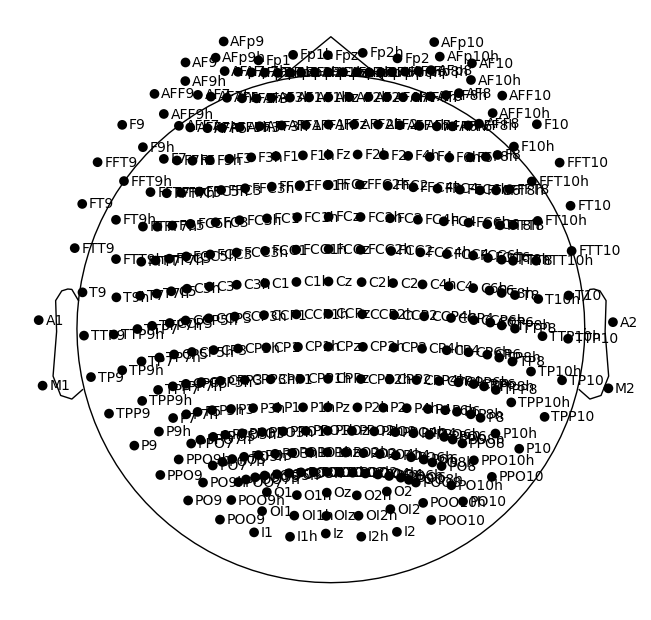

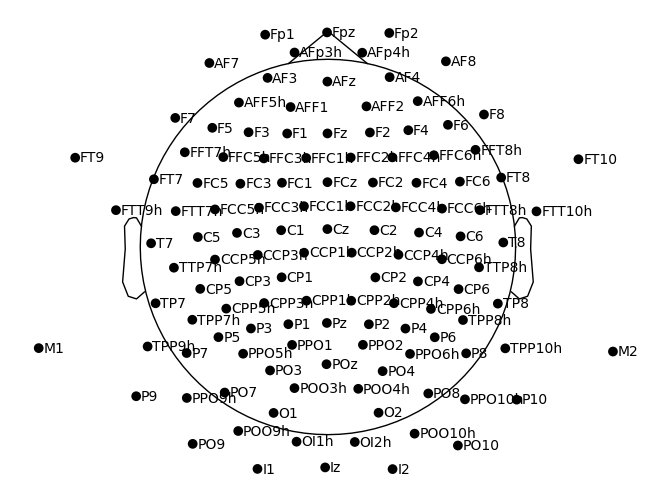

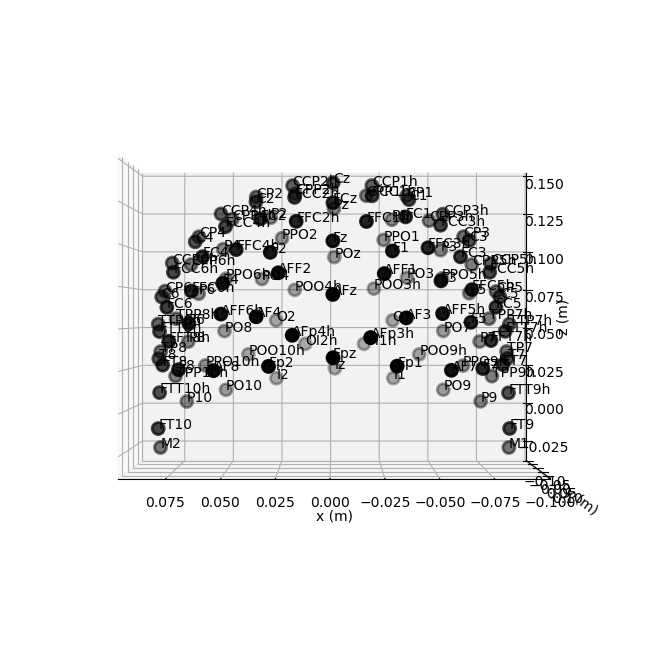

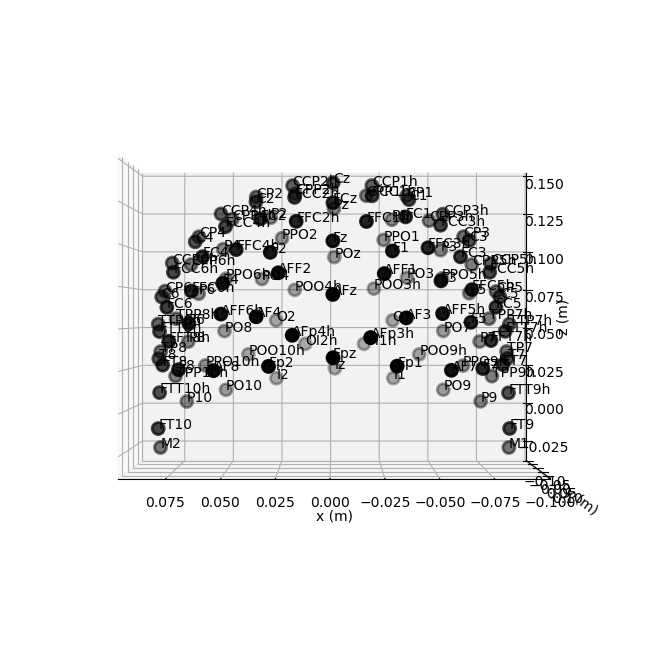

In [43]:
montage.plot(show_names = True)

raw.plot_sensors(
    kind="topomap",
    show_names=True,
    sphere="auto"
)
raw.plot_sensors(
    kind="3d",
    show_names=True
)


<h2>Build in plotting methods</h2>

<b>First how to plot all electrodes in TIME-DOMAIN</b>

>Scroll time

>Duration is 10 seconds 

>How many channels is shown on screen

<i><span style="color:red">QUEST: Understanding of what I see</span></i>

<span style="color:red">picks = mne.pick_types(raw.info, eeg=True, eog=False, emg=False)
raw.plot(picks=picks[:10], duration=10)
</span>

netreba, atrifakty

In [6]:
raw.plot(duration = 5, n_channels=30) 

#pics 
picks = ["Fz", "Cz", "Pz"]
raw.plot(picks=picks, duration=5)

raw.plot(picks=picks)


Using qt as 2D backend.


In [48]:
#manual plot????

channel = "Pz"
data, times = raw.get_data(picks=channel, return_times=True)

plt.figure(figsize=(10, 4))
plt.plot(times)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title(channel)
plt.show()


In [7]:
#croping time
tmin, tmax = 10, 30
raw_crop = raw.copy().crop(tmin=tmin, tmax=tmax)

#lepší použit get_data a start stop tady se to ukaze lip 
raw_crop.plot(duration=10)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Effective window size : 0.256 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/home/manka/miniconda3/envs/BooredCenv/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


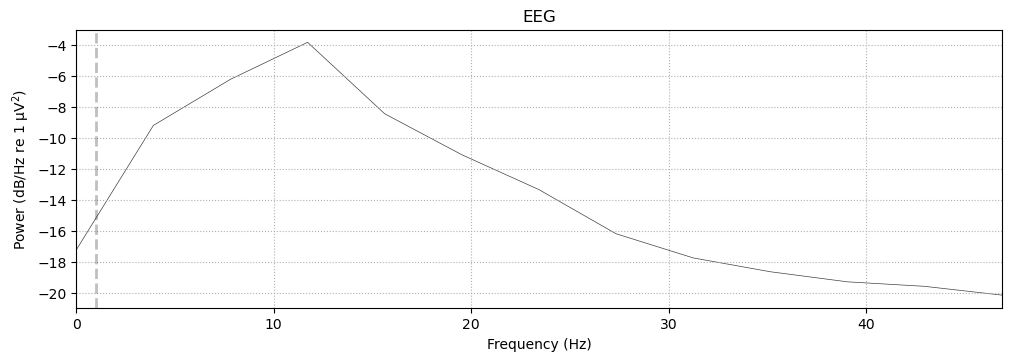

In [5]:
#PSD

this = raw.compute_psd(method= 'welch', fmax = 50).plot(picks='Pz') # jakou horni mez se zeptat
#picks="data", exclude="bads", amplitude=False // ploting



<h2>Using build in filter leads to bad looking power spectra>> use elephant</h2>

In [6]:
#Bands
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40)
}

raw_alpha = raw.copy().filter(8, 13)#fir_design="firwin" #tady pou69vat elephanta
raw_alpha.plot(picks=["Pz"], duration=10)


RuntimeError: By default, MNE does not load data into main memory to conserve resources. inst.filter requires raw data to be loaded. Use preload=True (or string) in the constructor or raw.load_data().

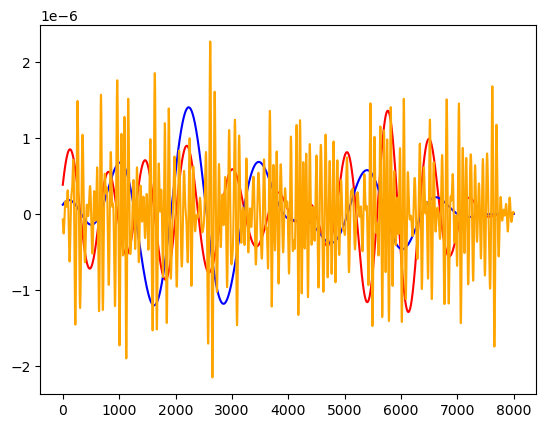

In [23]:
import elephant.signal_processing
# print(elephant.signal_processing)

start = 10*8000
stop = 11*8000
raw_filtered = elephant.signal_processing.butter(raw.get_data(picks=['Pz'], start=start, stop=stop), highpass_frequency=8, lowpass_frequency=13, sampling_frequency=8000, filter_function = "sosfiltfilt")
theta_raw_filtered = elephant.signal_processing.butter(raw.get_data(picks=['Pz'], start=start, stop=stop), highpass_frequency=4, lowpass_frequency=8, sampling_frequency=8000, filter_function = "sosfiltfilt")
gamma = elephant.signal_processing.butter(raw.get_data(picks=['Pz'], start=start, stop=stop), highpass_frequency=70, lowpass_frequency=150, sampling_frequency=8000, filter_function = "sosfiltfilt")
plt.plot(raw_filtered[0], color='red')
plt.plot(theta_raw_filtered[0], color='blue')
plt.plot(gamma[0], color='orange')
# plt.plot(raw.get_data(picks=['Pz'], start=start, stop=stop)[0], color='orange')

#Todoo: Amplituda, time oddeleni freqvenci

Zvopakovat celz toto cviceni abzch to pochopila a popsat lepe,- pouzit last year DONE

kouknout na videa a znovu projit zapisky, 
pokusit se pouzit cluster 
kouknout na nový počítač DONE

zkouknout vsko 5050


In [ ]:
import 